In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("C:/Users/akash/Documents/GitHub/Mini-Project-group-8/Sleep_Efficiency.csv")

In [3]:
df.head()


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,10,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,24,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,28,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


In [4]:
df.rename(columns=lambda x: x.replace(' ','_'), inplace=True)


In [5]:
df.columns

Index(['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup_time', 'Sleep_duration',
       'Sleep_efficiency', 'REM_sleep_percentage', 'Deep_sleep_percentage',
       'Light_sleep_percentage', 'Awakenings', 'Caffeine_consumption',
       'Alcohol_consumption', 'Smoking_status', 'Exercise_frequency'],
      dtype='object')

In [6]:
df.describe()

,ID,Age,Sleep_duration,Sleep_efficiency,REM_sleep_percentage,Deep_sleep_percentage,Light_sleep_percentage,Awakenings,Caffeine_consumption,Alcohol_consumption,Exercise_frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,436.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,23.002212,52.960177,24.831858,1.641204,23.653396,1.245413,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.972466,15.561713,15.150774,1.356762,30.202785,1.643336,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,20.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,51.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,60.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,27.000000,63.000000,27.250000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,56.000000,4.000000,200.000000,5.000000,5.000000


In [7]:
df.dtypes[df.dtypes != 'object']

ID                          int64
Age                         int64
Sleep_duration            float64
Sleep_efficiency          float64
REM_sleep_percentage        int64
Deep_sleep_percentage       int64
Light_sleep_percentage      int64
Awakenings                float64
Caffeine_consumption      float64
Alcohol_consumption       float64
Exercise_frequency        float64
dtype: object

In [8]:
df.dtypes[df.dtypes == 'object']

Gender            object
Bedtime           object
Wakeup_time       object
Smoking_status    object
dtype: object

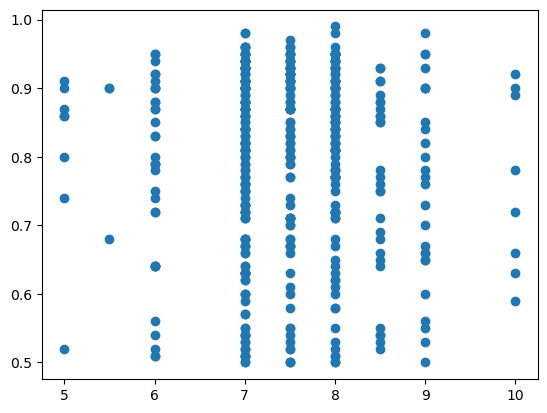

In [9]:
plt.scatter(x='Sleep_duration',y='Sleep_efficiency', data=df)

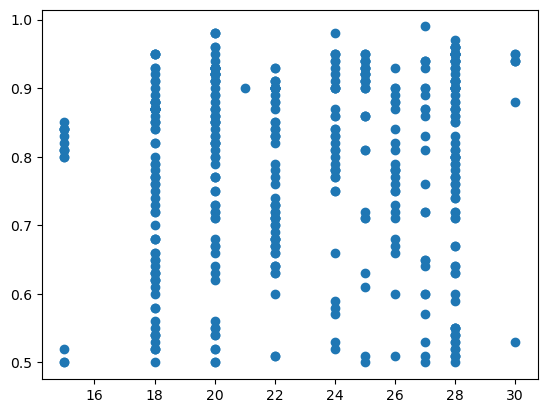

In [10]:
plt.scatter(x='REM_sleep_percentage',y = 'Sleep_efficiency',data = df)

In [11]:
df.query('REM_sleep_percentage<16')
#drop 258,447

,ID,Age,Gender,Bedtime,Wakeup_time,Sleep_duration,Sleep_efficiency,REM_sleep_percentage,Deep_sleep_percentage,Light_sleep_percentage,Awakenings,Caffeine_consumption,Alcohol_consumption,Smoking_status,Exercise_frequency
20,21,24,Male,2021-05-02 00:00:00,2021-05-02 08:00:00,8.0,0.83,15,75,10,3.0,0.0,NaN,No,2.0
62,63,29,Male,2021-05-03 21:00:00,2021-05-03 05:00:00,8.0,0.81,15,57,18,1.0,200.0,0.0,No,NaN
66,67,25,Male,2021-07-16 00:00:00,2021-07-16 07:00:00,7.0,0.84,15,70,15,4.0,0.0,4.0,No,2.0
81,82,29,Male,2021-07-11 21:00:00,2021-07-11 04:30:00,7.5,0.81,15,57,18,2.0,200.0,0.0,No,2.0
112,113,23,Male,2021-10-07 23:00:00,2021-10-07 07:00:00,8.0,0.80,15,65,15,4.0,75.0,0.0,No,2.0
203,204,38,Male,2021-07-11 23:00:00,2021-07-11 07:00:00,8.0,0.50,15,30,50,3.0,NaN,3.0,Yes,2.0
212,213,36,Female,2021-01-31 23:00:00,2021-01-31 06:30:00,7.5,0.80,15,55,20,1.0,50.0,2.0,No,4.0
257,258,27,Female,2021-05-31 22:00:00,2021-05-31 06:00:00,8.0,0.52,15,22,56,1.0,25.0,5.0,Yes,5.0
290,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,15,60,22,3.0,0.0,0.0,No,3.0
304,305,25,Male,2021-05-01 00:00:00,2021-05-01 08:00:00,8.0,0.84,15,70,15,4.0,0.0,4.0,No,NaN


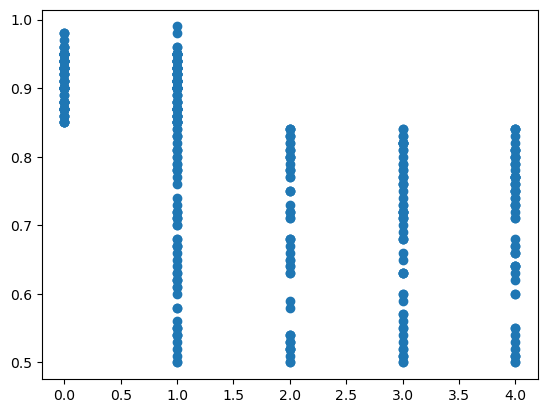

In [15]:
plt.scatter(x='Awakenings',y = 'Sleep_efficiency',data = df)

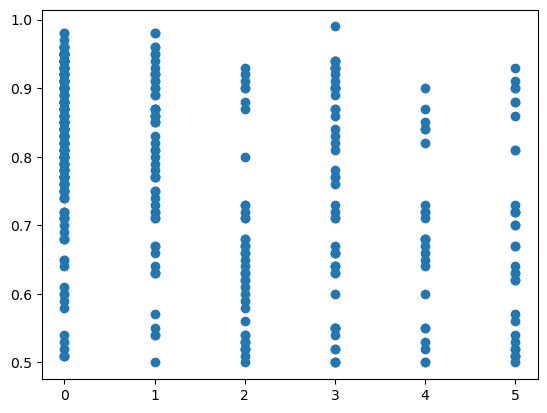

In [19]:
plt.scatter(x='Alcohol_consumption',y = 'Sleep_efficiency',data = df)

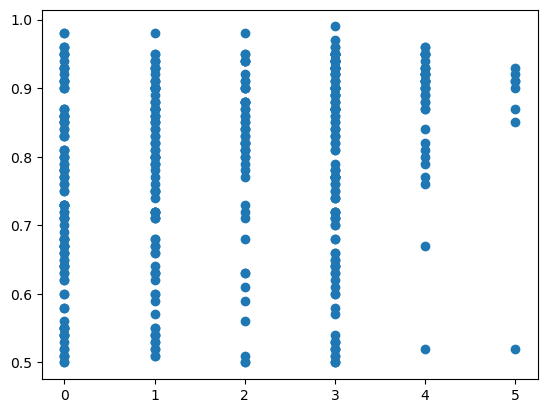

In [21]:
plt.scatter(x='Exercise_frequency',y = 'Sleep_efficiency',data = df)

In [31]:
df.query('Exercise_frequency==5')
#drop id-258

,ID,Age,Gender,Bedtime,Wakeup_time,Sleep_duration,Sleep_efficiency,REM_sleep_percentage,Deep_sleep_percentage,Light_sleep_percentage,Awakenings,Caffeine_consumption,Alcohol_consumption,Smoking_status,Exercise_frequency
15,16,32,Female,2021-12-06 22:00:00,2021-12-06 05:30:00,7.5,0.92,25,55,20,0.0,50.0,2.0,No,5.0
226,227,29,Female,2021-12-29 22:00:00,2021-12-29 05:30:00,7.5,0.93,25,55,20,0.0,0.0,0.0,No,5.0
247,248,29,Female,2021-09-01 22:00:00,2021-09-01 06:00:00,8.0,0.85,18,55,20,0.0,0.0,0.0,No,5.0
257,258,27,Female,2021-05-31 22:00:00,2021-05-31 06:00:00,8.0,0.52,15,22,56,1.0,25.0,5.0,Yes,5.0
333,334,27,Female,2021-01-23 22:00:00,2021-01-23 05:30:00,7.5,0.91,22,57,21,0.0,25.0,0.0,No,5.0
336,337,50,Female,2021-07-20 22:00:00,2021-07-20 05:00:00,7.0,0.90,22,55,20,1.0,0.0,NaN,No,5.0
416,417,49,Female,2021-01-04 22:00:00,2021-01-04 05:00:00,7.0,0.87,18,55,20,0.0,0.0,0.0,No,5.0
447,448,27,Female,2021-11-13 22:00:00,2021-11-13 05:30:00,7.5,0.91,25,57,21,0.0,0.0,0.0,No,5.0


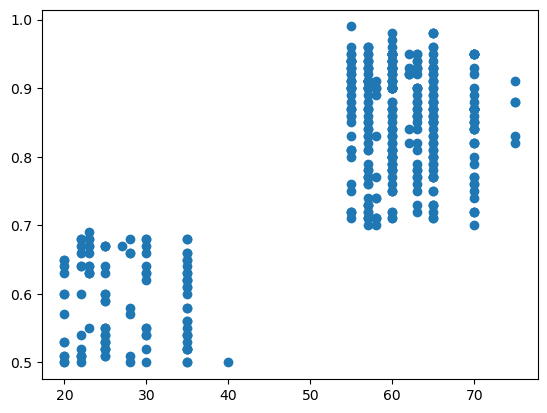

In [23]:
plt.scatter(x='Deep_sleep_percentage',y = 'Sleep_efficiency',data = df)

In [25]:
from scipy import stats
stats.zscore(df['Deep_sleep_percentage']).sort_values().tail(10)

77     1.096197
78     1.096197
331    1.096197
324    1.096197
369    1.096197
20     1.417854
24     1.417854
378    1.417854
347    1.417854
25     1.417854
Name: Deep_sleep_percentage, dtype: float64

In [27]:
stats.zscore(df['REM_sleep_percentage']).sort_values().tail(10)

97     1.259501
96     1.259501
104    1.259501
253    1.763525
440    1.763525
76     1.763525
364    1.763525
157    1.763525
127    1.763525
185    1.763525
Name: REM_sleep_percentage, dtype: float64

In [29]:
stats.zscore(df['Light_sleep_percentage']).sort_values().tail(10)

325    1.993401
415    1.993401
330    1.993401
172    1.993401
84     1.993401
106    1.993401
314    1.993401
35     1.993401
257    2.059477
345    2.059477
Name: Light_sleep_percentage, dtype: float64

In [33]:
values = [258,447]

In [37]:
df = df[df.ID.isin(values)==False]

In [39]:
pd.DataFrame(df.isnull().sum().sort_values(ascending=False))

,0
Caffeine_consumption,25
Awakenings,20
Alcohol_consumption,16
Exercise_frequency,5
ID,0
Age,0
Gender,0
Bedtime,0
Wakeup_time,0
Sleep_duration,0


In [45]:
df['Caffeine_consumption'].unique()

array([  0.,  50.,  nan,  25.,  75., 200., 100.])

In [47]:
df["Caffeine_consumption"] = df["Caffeine_consumption"].fillna(0)

In [49]:
df['Awakenings'].unique()

array([ 0.,  3.,  1.,  2.,  4., nan])

In [51]:
df["Awakenings"] = df["Awakenings"].fillna(0)

In [53]:
df['Awakenings'].unique()

array([0., 3., 1., 2., 4.])

In [55]:
df['Alcohol_consumption'].unique()

array([ 0.,  3.,  5.,  1.,  2., nan,  4.])

In [57]:
df["Alcohol_consumption"] = df["Alcohol_consumption"].fillna(0)

In [59]:
df['Exercise_frequency'].unique()

array([ 3.,  1.,  0.,  5.,  2.,  4., nan])

In [61]:
df["Exercise_frequency"] = df["Exercise_frequency"].fillna(0)

<Axes: >

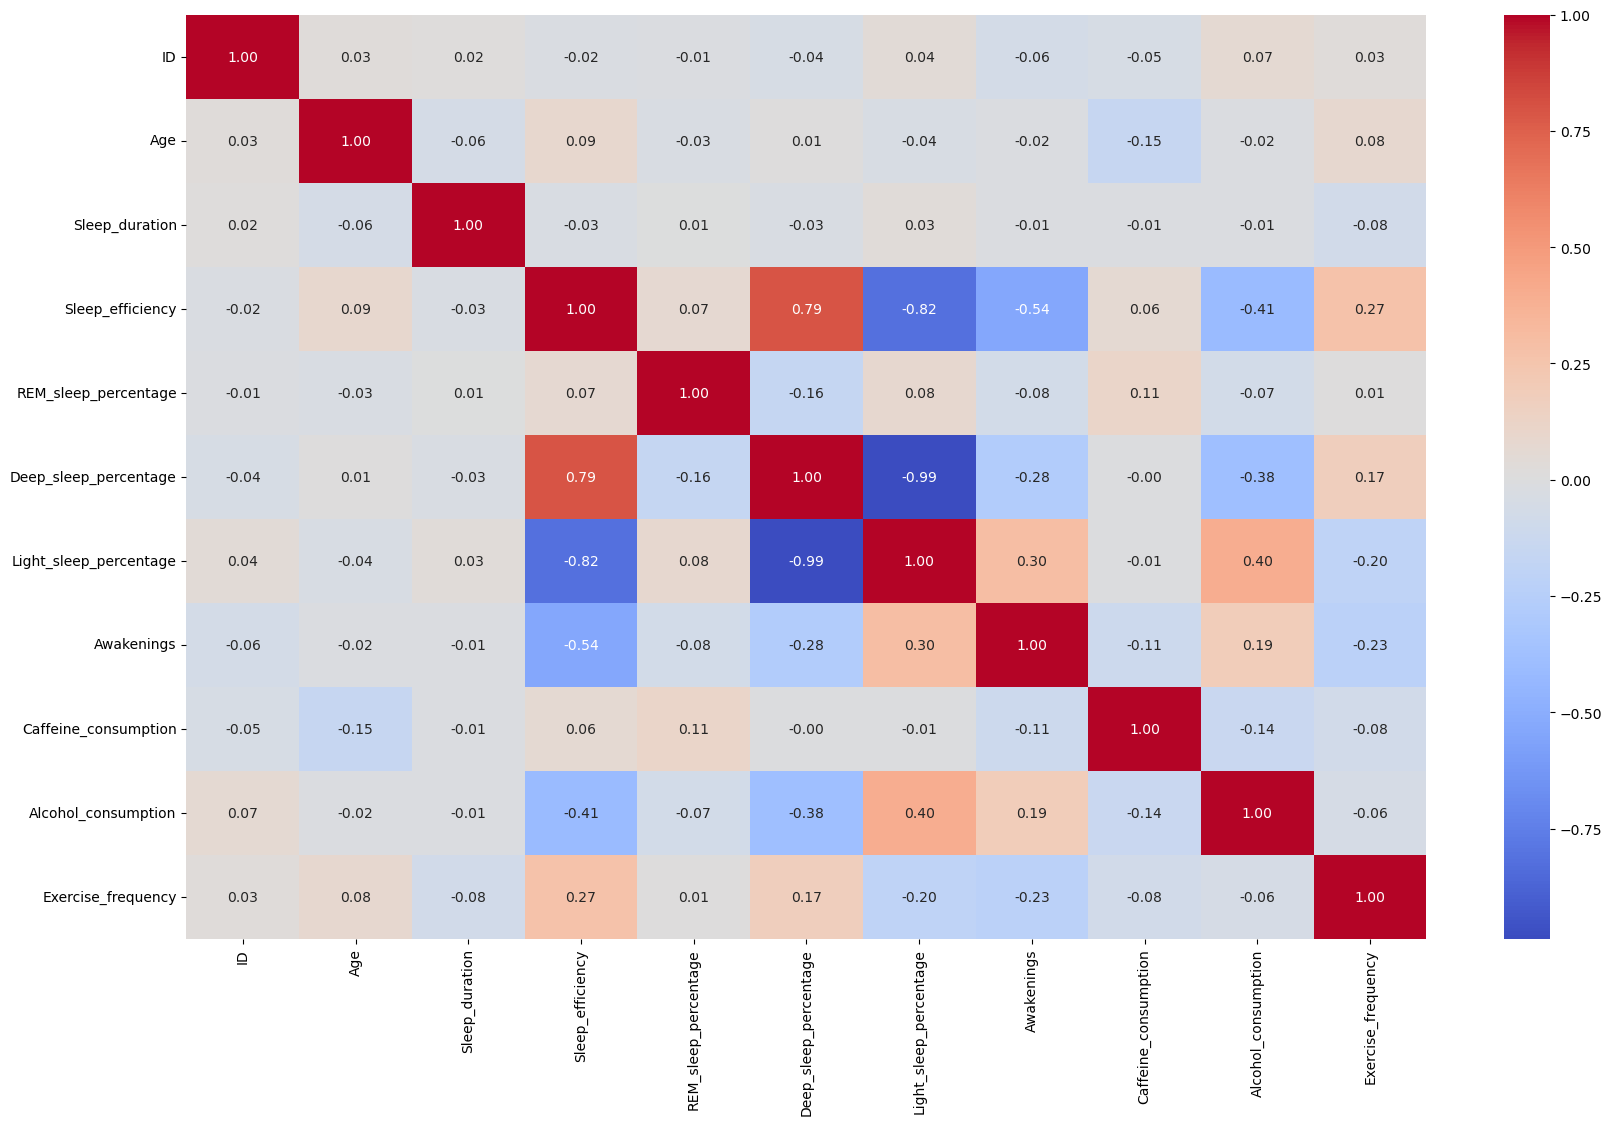

In [63]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [65]:
df = df.drop(columns=['Light_sleep_percentage'])

<Axes: xlabel='Sleep_efficiency', ylabel='Count'>

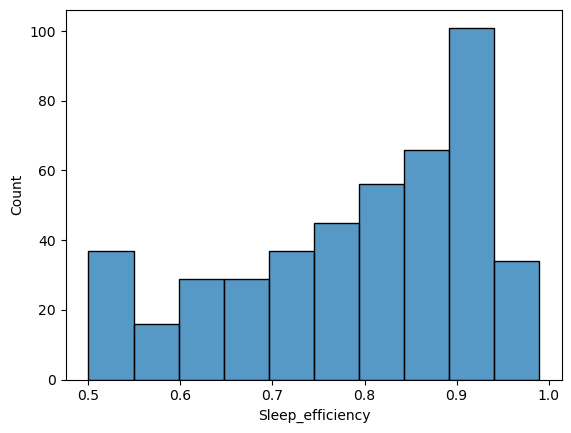

In [67]:
sns.histplot(
    df,
    x=df['Sleep_efficiency']
)

In [69]:
df['Sleep_efficiency']= np.log1p(df['Sleep_efficiency'])

<Axes: xlabel='Sleep_efficiency', ylabel='Count'>

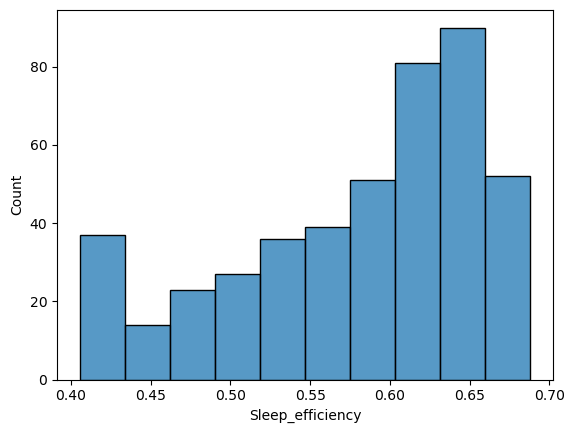

In [71]:
sns.histplot(
    df,
    x=df['Sleep_efficiency']
)

In [73]:
df.dtypes[df.dtypes=="object"]

Gender            object
Bedtime           object
Wakeup_time       object
Smoking_status    object
dtype: object

In [75]:
df.dtypes[df.dtypes!="object"]

ID                         int64
Age                        int64
Sleep_duration           float64
Sleep_efficiency         float64
REM_sleep_percentage       int64
Deep_sleep_percentage      int64
Awakenings               float64
Caffeine_consumption     float64
Alcohol_consumption      float64
Exercise_frequency       float64
dtype: object

In [77]:
df = df.drop(columns=["Bedtime","Wakeup_time"])

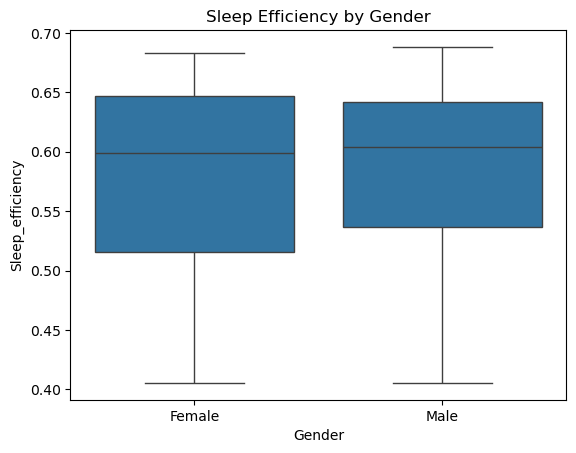

In [79]:
sns.boxplot(x=df['Gender'], y=df['Sleep_efficiency'])
plt.title("Sleep Efficiency by Gender")
plt.show()

In [83]:
from scipy.stats import ttest_ind

# Assuming 'Gender' is encoded as 'Male' and 'Female'
group1 = df[df['Gender'] == 'Male']['Sleep_efficiency']
group2 = df[df['Gender'] == 'Female']['Sleep_efficiency']

t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
print(f"T-test p-value: {p_value}")

if p_value < 0.05:
    print("Gender significantly affects sleep efficiency. Keep the column.")
else:
    print("Gender does not significantly affect sleep efficiency. Consider dropping it.")


T-test p-value: 0.7667571945893409
Gender does not significantly affect sleep efficiency. Consider dropping it.


In [87]:
df= df.drop(columns = ['Gender'])

In [97]:
df['Smoking_status'] = df['Smoking_status'].replace({'Yes': 1, 'No': 0}).astype(int)


In [99]:
df.dtypes[df.dtypes!="object"]

ID                         int64
Age                        int64
Sleep_duration           float64
Sleep_efficiency         float64
REM_sleep_percentage       int64
Deep_sleep_percentage      int64
Awakenings               float64
Caffeine_consumption     float64
Alcohol_consumption      float64
Smoking_status             int32
Exercise_frequency       float64
dtype: object

In [101]:
num_cols = df.select_dtypes(include=['int64', 'float64','int32']).columns
num_cols = num_cols.drop('Sleep_efficiency')

In [107]:
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [109]:
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols),
    ],
    remainder='passthrough', 
    n_jobs=-1)

In [111]:
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)
])

In [113]:
X = df.drop('Sleep_efficiency', axis=1)
y = df['Sleep_efficiency']

In [115]:
X_preprocessed = pipeline.fit_transform(X)

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=25)

In [119]:
lr = LinearRegression()

In [121]:
lr.fit(X_train, y_train)

LinearRegression()

In [123]:
y_pred_lr = lr.predict(X_test)

In [125]:
mean_squared_error(y_test, y_pred_lr)

0.001444738383698

In [129]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_lr)

In [131]:
print(r2)

0.725426843164855


In [133]:
import joblib
joblib.dump(lr, 'SleepAnalysis.pkl')  
print("Model saved successfully!")

Model saved successfully!
